# Model 1

## Goals:
- write ANN model for training set using Ligand and Protein descriptors only (No Interaction descriptors yet).
- study the contribution of descriptors to the performance of Model-1. 

# 0. Libraries

In [66]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from feature_engine.imputation import MeanMedianImputer
from feature_engine.selection import DropConstantFeatures, SmartCorrelatedSelection, DropDuplicateFeatures
from feature_engine.outliers import Winsorizer
from feature_engine.transformation import YeoJohnsonTransformer
from sklearn.preprocessing import StandardScaler
import os

import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 1. Reading Clean Dataset:

In [67]:
merged_df = pd.read_csv('V2-merged_df_noOutliers.csv')
merged_df.head(2)

,cid,Smiles,Standard Value,pIC50 Value,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,...,3d-P2s,3d-E1s,3d-E2s,3d-E3s,3d-Ts,3d-As,3d-Vs,3d-Ks,3d-Ds,QT-pIC50 Value
0,23647975,COc1cc(cc(Cc2cnc(N)nc2N)c1OC)C#CCCCC(O)=O,34.0,7.468521,1,-0.9874,0.974959,55.7857,55.717446,12,...,0.270792,0.568703,0.404621,0.409698,22.863896,123.556813,272.29810,0.506905,1.383022,0.624900
1,5578,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,2722.0,5.565112,0,-1.1990,1.437601,34.9926,43.448274,12,...,0.223644,0.526743,0.420964,0.415681,15.650156,58.403017,129.62338,0.521793,1.363389,-0.538272


In [68]:
merged_df.shape

(873, 2761)

In [69]:
cid_check = 5578 in merged_df['cid'].values
print(cid_check)

True


# 2. Reading FDA test:

In [70]:
fda_df = pd.read_csv('fda_to_check.csv')
fda_df.head(2)

,PubchemFP461,PubchemFP755,maxsBr,nFG12HeteroRing,nFG12Ring,PubchemFP193,PubchemFP494,JGI7,maxHBint6,PubchemFP737,...,nHsOH,PubchemFP580,VP-4,3d-RDF25v,PubchemFP636,3d-TDB7s,ETA_Epsilon_2,PubchemFP376,outlier,cid
0,0,0,0.0,0.0,0.0,0,0,0.017727,0.0,0,...,0.0,0,2.310611,7.669005,1,19.157705,0.86667,1,1,2082
1,0,0,0.0,1.0,1.0,0,0,0.011332,0.0,0,...,0.0,0,2.964759,18.458936,0,15.256270,0.80390,1,1,2118


# 3. Selecting FDA drugs from my Training set (to test the model):

In [71]:
# CID numbers fda-drugs from the training set:
cid_list = [4993, 5578, 126941]

# Create a DataFrame with the matching cids and reset index
cid_fda_tg = merged_df[merged_df['cid'].isin(cid_list)].reset_index(drop=True)

# Create a DataFrame without the matching cids and reset index
merged_df_noCID = merged_df[~merged_df['cid'].isin(cid_list)].reset_index(drop=True)

In [72]:
cid_fda_tg

,cid,Smiles,Standard Value,pIC50 Value,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,...,3d-P2s,3d-E1s,3d-E2s,3d-E3s,3d-Ts,3d-As,3d-Vs,3d-Ks,3d-Ds,QT-pIC50 Value
0,5578,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,2722.000000,5.565112,0,-1.1990,1.437601,34.9926,43.448274,12,...,0.223644,0.526743,0.420964,0.415681,15.650156,58.403017,129.623380,0.521793,1.363389,-0.538272
1,126941,CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(cc1)C(=O)N[C@@H...,29.625000,7.528342,2,-2.8974,8.394927,54.4148,62.679446,16,...,0.133938,0.619849,0.448537,0.367085,32.001858,151.900877,325.797982,0.740461,1.435471,0.705420
2,4993,CCc1nc(N)nc(N)c1-c1ccc(Cl)cc1,311.076923,6.507132,0,-0.9922,0.984461,22.8701,36.368309,12,...,0.277970,0.391132,0.351536,0.318947,10.959380,31.357381,64.407180,0.438266,1.061614,0.112086


## 5.5. Important features only

### 5.5.1. Reading file with Importance of the Descriptors

In [73]:
df_imp = pd.read_csv('V2-feature_importance_model_PermImp.csv')
df_imp.head(2)

,Feature,Importance
0,PubchemFP461,0.009318
1,PubchemFP755,0.006300


In [74]:
df_imp.shape

(1858, 2)

### 5.5.2. Selecting All Features with positive contribution:

In [75]:
df_imp_pos = df_imp[df_imp['Importance']>0]
df_imp_pos.shape[0]

1030

In [76]:
df_imp_pos['Importance'].min()

1.0001948053228738e-06

In [77]:
df_imp_pos['Importance'].max()

0.0093179311212038

In [78]:
features_all_pos = df_imp_pos['Feature'].to_list()

In [79]:
len(features_all_pos)

1030

### 5.5.3. Positive Features by Groups: 

#### Grouping Features buy Importance and Analyze:


In [80]:
import pandas as pd

# Example DataFrame setup; replace with your actual DataFrame
# df_imp_pos is assumed to be defined and contain a column 'Importance'

# Define the new bin edges based on the new interval
bins = [1e-06, 1e-05, 1e-04, 1e-03, 1e-02]
#bins = [5e-04, 7.5e-04, 1e-03, 5e-03, 7.5e-03, 2e-02]

# Reverse the order of the labels to match the bins
labels = [f"Group_{i+1}" for i in range(len(bins) - 1)][::-1]

# Create the 'Group' column using pd.cut with the new bins and labels
df_imp_pos['Group'] = pd.cut(df_imp_pos['Importance'], bins=bins, labels=labels, right=False)

# Display the DataFrame with the new 'Group' column
df_imp_pos.head()

,Feature,Importance,Group
0,PubchemFP461,0.009318,Group_1
1,PubchemFP755,0.006300,Group_1
2,maxsBr,0.004837,Group_1
3,nFG12HeteroRing,0.003928,Group_1
4,nFG12Ring,0.003861,Group_1


In [81]:
# Filter data for Group_1
features_Group_1 = df_imp_pos[df_imp_pos['Group'] == 'Group_1']
features_Group_2 = df_imp_pos[df_imp_pos['Group'] == 'Group_2']
features_Group_3 = df_imp_pos[df_imp_pos['Group'] == 'Group_3']
features_Group_4 = df_imp_pos[df_imp_pos['Group'] == 'Group_4']
#features_Group_5 = df_imp_pos[df_imp_pos['Group'] == 'Group_5']

In [82]:
features_Group_1_arr = features_Group_1['Feature'].to_list()
features_Group_2_arr = features_Group_2['Feature'].to_list()
features_Group_3_arr = features_Group_3['Feature'].to_list()
features_Group_4_arr = features_Group_4['Feature'].to_list()
#features_Group_5_arr = features_Group_5['Feature'].to_list()

# 9. Groups: 1,2,3,4
(all positive features)

## 9.1. Splitting Data

In [246]:
# Reset Indexes:
merged_df = merged_df.reset_index(drop=True)

In [247]:
# FOR MODEL

feat_imp = features_Group_1_arr + features_Group_2_arr + features_Group_3_arr

X = merged_df[feat_imp]
y = merged_df['pIC50 Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state = 42)

In [248]:
col_fda = feat_imp + ['cid']

df_1 = fda_df[col_fda]
df_2 = cid_fda_tg[col_fda]

df_combined = pd.concat([df_1, df_2], axis=0)

X_fda_test = df_combined[feat_imp]
y_fda = df_combined[['cid']]

In [249]:
df_1.shape

(193, 1021)

## 9.2. Missing Data Imputation

In [250]:
# Initialize the imputer with median imputation method
imputer = MeanMedianImputer(imputation_method='median')

# Fit the imputer to the training data
imputer.fit(X_train)

# Transform the training data
X_train = imputer.transform(X_train)
X_test = imputer.transform(X_test)

#X_tg = imputer.transform(X_tg_test)
X_fda = imputer.transform(X_fda_test)

## 5.7. Removing Constants and Dublicated

In [251]:
%%time

# Drop constant
drop_const = DropConstantFeatures(tol=0.999)

drop_const.fit(X_train)
X_train = drop_const.transform(X_train)
X_test = drop_const.transform(X_test)

X_fda = drop_const.transform(X_fda)
print(X_train.shape)

# Drop duplicates
drop_dup = DropDuplicateFeatures()

drop_dup.fit(X_train)
X_train = drop_dup.transform(X_train)
X_test = drop_dup.transform(X_test)

X_fda = drop_dup.transform(X_fda)
print(X_train.shape)

(742, 1020)
(742, 1020)
CPU times: user 2.1 s, sys: 146 ms, total: 2.25 s
Wall time: 2.26 s


## 9.3. Outliers

In [252]:
%time

# Initialize Winsorizer transformer
winsorizer = Winsorizer(capping_method='gaussian', tail='both')

# Fit and transform on training data
winsorizer.fit(X_train)

X_train = winsorizer.transform(X_train)
X_test = winsorizer.transform(X_test)

X_fda = winsorizer.transform(X_fda)
#X_tg = winsorizer.transform(X_tg)

CPU times: user 6 µs, sys: 0 ns, total: 6 µs
Wall time: 10.5 µs


## 9.4. YeoJohnsonTransformer:

In [253]:
%time

from feature_engine.transformation import YeoJohnsonTransformer

#Randomly sample 3736 rows from df_t25
yeo_trans = YeoJohnsonTransformer()
yeo_trans.fit(X_train)

X_train = yeo_trans.transform(X_train)
X_test = yeo_trans.transform(X_test)

X_fda = yeo_trans.transform(X_fda)
#X_tg = yeo_trans.transform(X_tg)

CPU times: user 6 µs, sys: 1 µs, total: 7 µs
Wall time: 11.2 µs


## 9.5. Scaling:

In [254]:
%time

import pandas as pd
from sklearn.preprocessing import StandardScaler

# Instantiate the StandardScaler
scaler = StandardScaler()

# Fit and transform on the training data
scaler.fit(X_train)

# Scale the training data
X_train_eda = scaler.transform(X_train)
X_test_eda = scaler.transform(X_test)
X_fda_eda = scaler.transform(X_fda)
#X_tg_eda = scaler.transform(X_tg)

# Convert the numpy arrays back to DataFrames and assign column names
X_train = pd.DataFrame(X_train_eda, columns=X_train.columns)
X_test = pd.DataFrame(X_test_eda, columns=X_test.columns)
X_fda = pd.DataFrame(X_fda_eda, columns=X_fda.columns)
#X_tg = pd.DataFrame(X_tg_eda, columns=X_tg_test.columns)


CPU times: user 5 µs, sys: 1 µs, total: 6 µs
Wall time: 10.5 µs


# Augmentation:

In [255]:
# Concatenate X_train and X_test to get the full feature set
X_f = pd.concat([X_train, X_test], axis=0)

# Concatenate y_train and y_test to get the full target variable
y_f = pd.concat([y_train, y_test], axis=0)

# Reset the indices to ensure consistency
#X_f = X_f.reset_index(drop=True)
#y_f = y_f.reset_index(drop=True)

In [256]:
X, X_test_val, y, y_test_val = train_test_split(X_f, y_f, test_size=0.15, random_state = 42)

In [257]:
print(X_train.shape)
print(X_test.shape)

(742, 1020)
(131, 1020)


In [258]:
import numpy as np
import pandas as pd

# Assuming X and y are your pandas DataFrames
# Set the noise factor (you can adjust this based on the data scale)
noise_factor = 0.01
noise_factor_2 = 0.001

# Create empty lists to store augmented data
X_augmented_list = []
y_augmented_list = []

# Loop over each data point and create four augmented cases per point
for i in range(len(X)):
    # Original row
    X_original = X.iloc[i]
    y_original = y.iloc[i]
    
    # Case 1: Add Gaussian noise
    X_augmented_1 = X_original + np.random.normal(0, noise_factor, X_original.shape)
    
    # Case 2: Add Gaussian noise
    X_augmented_2 = X_original + np.random.normal(0, noise_factor_2, X_original.shape)
    
    # Append all augmented cases and the original target to the lists
    X_augmented_list.append(X_augmented_1)
    X_augmented_list.append(X_augmented_2)
    
    y_augmented_list.append(y_original)
    y_augmented_list.append(y_original)

# Convert lists back to pandas DataFrames
X_augmented = pd.DataFrame(X_augmented_list, columns=X.columns)
y_augmented = pd.Series(y_augmented_list, name=y.name)

# Combine the original and augmented data
X_combined = pd.concat([X, X_augmented], axis=0).reset_index(drop=True)
y_combined = pd.concat([y, y_augmented], axis=0).reset_index(drop=True)

# Check the shapes of the combined data
print("X_combined shape:", X_augmented.shape)
print("y_combined shape:", y_augmented.shape)

# Check a sample of the augmented data
print(X_augmented.head())
print(y_augmented.head())






X_combined shape: (1484, 1020)
y_combined shape: (1484,)
     PubchemFP461  PubchemFP755    maxsBr  nFG12HeteroRing  nFG12Ring  \
31      -0.068654     -0.411875 -0.132198        -0.278681  -0.304296   
31      -0.073098     -0.411066 -0.138699        -0.291769  -0.300227   
235     -0.080568     -0.414585 -0.143916        -0.292387  -0.310179   
235     -0.073304     -0.410825 -0.138768        -0.294440  -0.303469   
381     -0.067284     -0.417474 -0.121888        -0.313027  -0.288843   

     PubchemFP193  PubchemFP494      JGI7  maxHBint6  PubchemFP737  ...  \
31      -0.168777     -0.088607 -0.630951  -0.929167      2.052084  ...   
31      -0.165999     -0.104361 -0.638505  -0.923859      2.045636  ...   
235     -0.155225     -0.104397  3.045642  -0.927751     -0.487049  ...   
235     -0.166114     -0.102644  3.045753  -0.924247     -0.487909  ...   
381     -0.168679     -0.095803 -0.852801   0.785734      2.042785  ...   

     SpMax3_Bhv  3d-RDF50u     3d-Tv   SHCsats  maxHB

In [259]:
X_train = X_augmented.copy()
y_train = y_augmented.copy()

X_test = X_test_val.copy()
y_test = y_test_val.copy()

## 9.6. Multiple ANN Model (Average of 5 runs)

## 9.6. ANN-Models: fda drugs with known pIC50

In [260]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import r2_score, mean_absolute_error
import tensorflow as tf
import random

# Set random seeds for reproducibility
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

# Initialize variables to store results
y_preds = []
maes = []
r2_scores = []

# Ensure X_fda has the same columns as X_train
X_fda_aligned = X_fda.copy()  # Align columns with X_train

# Run the model 5 times
for i in range(5):
    print(f"Running model {i + 1}")
    # Define the neural network model
    model_1 = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(16, activation='relu'),
        BatchNormalization(),
        Dense(1, activation='linear')
    ])

    # Compile the model
    optimizer = Adam(learning_rate=0.0007)
    model_1.compile(
        optimizer=optimizer,
        loss='mean_squared_error',
        metrics=['mae']
    )

    # Apply learning rate reduction on plateau
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=20, min_lr=0.000001)

    # Define the EarlyStopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=60,
        restore_best_weights=True
    )

    # Train the model
    history_improved = model_1.fit(
        X_train,
        y_train,
        batch_size=32,
        epochs=200,
        validation_data=(X_test, y_test),
        shuffle=True,
        verbose=0,
        callbacks=[reduce_lr, early_stopping]
    )

    # Predict on the test set
    y_pred = model_1.predict(X_test)
    y_preds.append(y_pred.flatten())

    # Calculate MAE and R^2
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Append MAE and R^2 to lists
    maes.append(mae)
    r2_scores.append(r2)

    # Predict pIC50 for X_fda and store the result
    X_fda_test[f'pIC50_{i+1}'] = model_1.predict(X_fda_aligned).flatten()

    # Delete the model to free up memory before the next iteration
    del model_1

# After the loop, calculate the average pIC50 prediction for X_fda
X_fda_test['pIC50_avrg'] = X_fda_test[[f'pIC50_{i+1}' for i in range(5)]].mean(axis=1)

# Convert y_preds list to a DataFrame
y_preds_df = pd.DataFrame(y_preds).T
y_preds_df.columns = [f'y_pred_run_{i+1}' for i in range(5)]
y_preds_df.index = y_test.index  # Use the same index as y_test

# Calculate the average y_pred across all runs
y_preds_df['average_y_pred'] = y_preds_df.mean(axis=1)

# Add y_test to the DataFrame
y_preds_df['y_test'] = y_test

# Calculate MAE and R^2 for the average predictions
average_mae = mean_absolute_error(y_test, y_preds_df['average_y_pred'])
average_r2 = r2_score(y_test, y_preds_df['average_y_pred'])

# Create a summary DataFrame
summary_df = pd.DataFrame({
    'Run': [f'Run {i+1}' for i in range(5)] + ['Average'],
    'R2': r2_scores + [average_r2],
    'MAE': maes + [average_mae]
})

# Display summary of R2 and MAE across runs
print(summary_df)

# Display the first few rows of X_fda with the pIC50 predictions
print(X_fda.head())


Running model 1
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step
Running model 2
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step
Running model 3
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 771us/step
Running model 4
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 743us/step
Running model 5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 783us/step
       Run        R2       MAE
0    Run 1  0.821182  0.403523
1    Run 2  0.831904  0.379283
2    Run 3  0.819723  0.383020
3    Run 4  0.838702  0.365745
4    Run 5  0.835222  0.365810
5  Average  0.848226  0.359835
   PubchemFP461  PubchemFP755    maxsBr  nFG12HeteroRing  nFG12Ring  \
0     -0.073621     -0.410492 -0.138675        -0.293911  -0.301954   
1     -0.073621     -0.410492 -0.138675         3.402392   3.311758   
2     -0.073621     -0.410492 -0.138675        -0.293911  -0.301954   
3     -0.073621     -0.410492 -0.1

In [230]:
# Sort X_fda by 'pIC50_avrg' in descending order
X_fda_sorted = X_fda_test.sort_values(by='pIC50_avrg', ascending=False)

# Display the sorted DataFrame
X_fda_sorted['pIC50_avrg'].head(10) 

3      7.426595
173    7.348497
17     7.195217
132    7.087060
179    6.931161
170    6.883524
55     6.826379
90     6.760686
36     6.576994
1      6.537757
Name: pIC50_avrg, dtype: float32

In [266]:
# Ensure that the indices of X_fda_sorted and y_fda match
df_combined = pd.concat([X_fda_test, y_fda], axis=1)
df_combined = df_combined.sort_values(by='pIC50_avrg', ascending=False)

df_combined[['pIC50_avrg','cid']] 

,pIC50_avrg,cid
3,7.426595,2391
173,7.348497,60150535
17,7.195217,3308
132,7.087060,9863827
179,6.931161,71731823
...,...,...
96,1.998426,471161
156,1.302756,24831714
154,-4.789454,24812758
136,-7.983699,9887712


In [270]:
top_50 = df_combined[['pIC50_avrg','cid']].head(55)

In [271]:
top_50

,pIC50_avrg,cid
3,7.426595,2391
173,7.348497,60150535
17,7.195217,3308
132,7.087060,9863827
179,6.931161,71731823
170,6.883524,56944144
55,6.826379,5546
90,6.760686,214348
36,6.576994,4170
1,6.537757,126941


In [278]:
top_ten_df = top_50.head(10)

In [279]:
# Extract the top 10 'cid' values
top_ten_cid = top_ten_df['cid'].head(10).tolist()

# Print or save the result
print(top_ten_cid)

[2391, 60150535, 3308, 9863827, 71731823, 56944144, 5546, 214348, 4170, 126941]


# LA Calculation:

# 2. FDA Dataset (PubChem):

In [273]:
df_fda = pd.read_csv('PubChem_FDA-approved_NoInorganics.csv')
df_fda.head(2)

,cid,cmpdname,cmpdsynonym,mw,mf,polararea,complexity,xlogp,heavycnt,hbonddonor,...,gpidcnt,gpfamilycnt,meshheadings,annothits,annothitcnt,aids,cidcdate,sidsrcname,depcatg,annotation
0,176,Acetic Acid,acetic acid|ethanoic acid|64-19-7|Acetic acid ...,60.05,C2H4O2,37.3,31.0,-0.2,4,1,...,288903,167925,Acetic Acid,Agrochemical Information|Biological Test Resul...,19,248|17814|17815|17816|17817|17818|17819|17820|...,20040916,001Chemical|10X CHEM|1st Scientific|3B Scienti...,Chemical Vendors|Curation Efforts|Governmental...,C254 - Anti-Infective Agent|D000890 - Anti-Inf...
1,244,Benzyl Alcohol,benzyl alcohol|phenylmethanol|benzenemethanol|...,108.14,C7H8O,20.2,55.4,1.1,8,1,...,430390,147130,Benzyl Alcohol,Biological Test Results|Interactions and Pathw...,18,155|157|161|165|167|175|192|248|328|330|421|42...,20040916,001Chemical|10X CHEM|3B Scientific (Wuhan) Cor...,Chemical Vendors|Curation Efforts|Governmental...,"P - Antiparasitic products, insecticides and r..."


In [276]:
df_fda.columns = df_fda.columns.str.strip()

# Select the rows where 'cid' is in the list
top_ten = df_fda[df_fda['cid'].isin(top_ten_cid)]


In [280]:
# Ensure there are no leading/trailing spaces in the column names
top_ten_df.columns = top_ten_df.columns.str.strip()
top_ten.columns = top_ten.columns.str.strip()

# Merge the two DataFrames on the 'cid' column
top_ten_final = pd.merge(top_ten, top_ten_df[['cid', 'pIC50_avrg']], on='cid', how='left')

In [281]:
top_ten_final.head(50)

,cid,cmpdname,cmpdsynonym,mw,mf,polararea,complexity,xlogp,heavycnt,hbonddonor,...,gpfamilycnt,meshheadings,annothits,annothitcnt,aids,cidcdate,sidsrcname,depcatg,annotation,pIC50_avrg
0,2391,Bisacodyl,bisacodyl|603-50-9|Dulcolax|Bicol|Theralax|Sk-...,361.40,C22H19NO4,65.5,457.0,3.8,27,0,...,3845,Bisacodyl,Biological Test Results|Interactions and Pathw...,16,1|3|5|7|9|11|13|15|17|19|21|23|25|27|29|31|33|...,20050325,001Chemical|10X CHEM|3B Scientific (Wuhan) Cor...,Chemical Vendors|Curation Efforts|Governmental...,A - Alimentary tract and metabolism > A06 - Dr...,7.426595
1,3308,Etodolac,etodolac|41340-25-4|Etodolic acid|Lodine|Ultra...,287.35,C17H21NO3,62.3,400.0,2.8,21,2,...,13449,Etodolac,Biological Test Results|Interactions and Pathw...,16,179|330|357|361|364|368|371|373|374|375|377|41...,20050325,001Chemical|10X CHEM|3B Scientific (Wuhan) Cor...,Chemical Vendors|Curation Efforts|Governmental...,C78272 - Agent Affecting Nervous System > C241...,7.195217
2,4170,Metolazone,metolazone|17560-51-9|Zaroxolyn|Mykrox|Diulo|O...,365.80,C16H16ClN3O3S,101.0,594.0,4.1,24,2,...,3560,Metolazone,Biological Test Results|Interactions and Pathw...,16,377|875|879|880|881|884|885|886|887|889|892|89...,20050325,001Chemical|10X CHEM|1st Scientific|3B Scienti...,Chemical Vendors|Curation Efforts|Governmental...,C - Cardiovascular system > C03 - Diuretics > ...,6.576994
3,5546,Triamterene,"triamterene|396-01-0|6-phenylpteridine-2,4,7-t...",253.26,C12H11N7,130.0,307.0,1.0,19,3,...,9831,Triamterene,Biological Test Results|Interactions and Pathw...,17,179|248|256|357|361|364|368|371|373|374|375|41...,20050325,001Chemical|10X CHEM|3B Scientific (Wuhan) Cor...,Chemical Vendors|Curation Efforts|Governmental...,C - Cardiovascular system > C03 - Diuretics > ...,6.826379
4,126941,Methotrexate,methotrexate|59-05-2|Rheumatrex|Amethopterin|M...,454.40,C20H22N8O5,211.0,704.0,-1.8,33,5,...,80857,Methotrexate,Biological Test Results|Interactions and Pathw...,18,1|3|5|7|9|11|13|15|17|19|21|23|25|27|29|31|33|...,20050624,001Chemical|10X CHEM|1st Scientific|3B Scienti...,Chemical Vendors|Curation Efforts|Governmental...,D007155 - Immunologic Factors > D007166 - Immu...,6.537757
5,214348,Deferasirox,Deferasirox|201530-41-8|Exjade|ICL 670|ICL670A...,373.40,C21H15N3O4,109.0,540.0,3.8,28,3,...,840,Deferasirox,Biological Test Results|Interactions and Pathw...,16,419505|454621|454622|454623|460407|460409|4604...,20050809,001Chemical|10X CHEM|1st Scientific|3B Scienti...,Chemical Vendors|Curation Efforts|Governmental...,D064449 - Sequestering Agents > D002614 - Chel...,6.760686
6,9863827,Ozenoxacin,Ozenoxacin|245765-41-7|Xepi|Ozenoxacin Cream|T...,363.40,C21H21N3O3,82.5,645.0,4.1,27,2,...,66,NaN,Biological Test Results|Interactions and Pathw...,11,1479145|1479147|1479149|1479150|1645845|164584...,20061025,001Chemical|10X CHEM|A2B Chem|AA BLOCKS|Aaron ...,Chemical Vendors|Curation Efforts|Governmental...,C254 - Anti-Infective Agent > C258 - Antibioti...,7.087060
7,56944144,Lemborexant,Lemborexant|1369764-02-2|Dayvigo|E-2006|E2006|...,410.40,C22H20F2N4O2,77.0,612.0,3.2,30,1,...,31,NaN,Biological Test Results|Interactions and Pathw...,15,1231765|1231766|1231767|1231768|1231769|123177...,20120423,10X CHEM|1st Scientific|A2B Chem|AA BLOCKS|Aar...,Chemical Vendors|Curation Efforts|Governmental...,C78272 - Agent Affecting Nervous System > C142...,6.883524
8,60150535,Finerenone,Finerenone|1050477-31-0|Kerendia|Finerenone (B...,378.40,C21H22N4O3,110.0,670.0,2.4,28,2,...,132,NaN,Biological Test Results|Interactions and Pathw...,14,705911|705916|722892|1159386|1159387|1159389|1...,20120910,001Chemical|10X CHEM|A2B Chem|AA BLOCKS|Aaron ...,Chemical Vendors|Curation Efforts|Governmental...,C - Cardiovascular system > C03 - Diuretics > ...,7.348497
9,71731823,Lorlatinib,Lorlatinib|1454846-35-5|PF-06463922|Loratinib|...,406.40,C21H19FN6O2,110.0,700.0,1.5,30,1,...,363,NaN,Biological Test Results|Interactions and Pathw...,15,1|3|5|7|9|13|15|19|21|23|25|29|31|33|35|37|39|...,20131017,10X 

In [282]:
top_ten_final['LE'] = 1.37*top_ten_final['pIC50_avrg']/top_ten_final['heavycnt']
top_ten_final['LE']

0    0.376831
1    0.469402
2    0.375437
3    0.492218
4    0.271416
5    0.330791
6    0.359603
7    0.314348
8    0.359551
9    0.316523
Name: LE, dtype: float64

In [283]:
top_ten_final['BEI'] = 1000*top_ten_final['pIC50_avrg']/top_ten_final['mw']
top_ten_final['BEI']

0    20.549515
1    25.039907
2    17.979756
3    26.954037
4    14.387669
5    18.105747
6    19.502093
7    16.772720
8    19.419918
9    17.055024
Name: BEI, dtype: float64

In [284]:
top_ten_final['LLE'] = top_ten_final['pIC50_avrg'] - top_ten_final['xlogp']
top_ten_final['LLE']

0    3.626595
1    4.395217
2    2.476994
3    5.826379
4    8.337757
5    2.960686
6    2.987060
7    3.683524
8    4.948497
9    5.431161
Name: LLE, dtype: float64

In [285]:
top_ten_final['SEI'] = 100*top_ten_final['pIC50_avrg']/top_ten_final['polararea']
top_ten_final['SEI']

0    11.338313
1    11.549305
2     6.511876
3     5.251061
4     3.098463
5     6.202464
6     8.590376
7     8.939642
8     6.680452
9     6.301056
Name: SEI, dtype: float64

In [294]:
print(top_ten_final[['cmpdname','cid','pIC50_avrg','LE','BEI','LLE','SEI']])

       cmpdname       cid  pIC50_avrg        LE        BEI       LLE  \
0     Bisacodyl      2391    7.426595  0.376831  20.549515  3.626595   
1      Etodolac      3308    7.195217  0.469402  25.039907  4.395217   
2    Metolazone      4170    6.576994  0.375437  17.979756  2.476994   
3   Triamterene      5546    6.826379  0.492218  26.954037  5.826379   
4  Methotrexate    126941    6.537757  0.271416  14.387669  8.337757   
5   Deferasirox    214348    6.760686  0.330791  18.105747  2.960686   
6    Ozenoxacin   9863827    7.087060  0.359603  19.502093  2.987060   
7   Lemborexant  56944144    6.883524  0.314348  16.772720  3.683524   
8    Finerenone  60150535    7.348497  0.359551  19.419918  4.948497   
9    Lorlatinib  71731823    6.931161  0.316523  17.055024  5.431161   

         SEI  
0  11.338313  
1  11.549305  
2   6.511876  
3   5.251061  
4   3.098463  
5   6.202464  
6   8.590376  
7   8.939642  
8   6.680452  
9   6.301056  


'Click on the photo to zoom it'

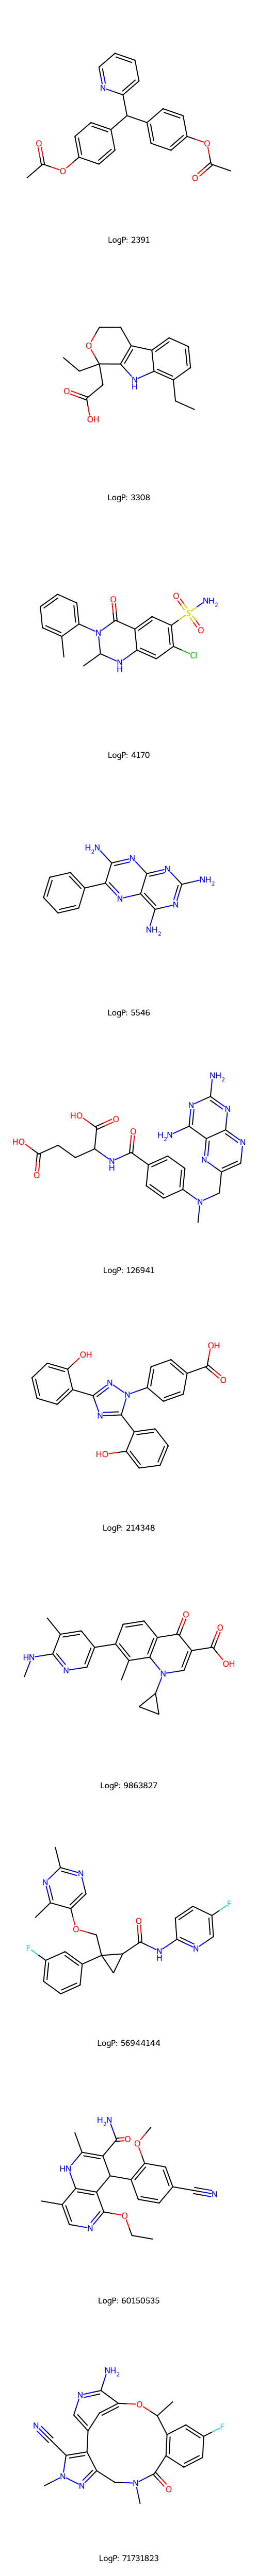

In [287]:
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, AllChem
from rdkit.Chem.Draw import IPythonConsole

def show_smiles(smiles):
  """
  generate 2D representations of the molecules and color-code them by logP
  :param data_frame: list of smiles
  """
  # Convert the SMILES strings to RDKit molecules
  molecules = [Chem.MolFromSmiles(smile) for smile in smiles]

  # Draw the first molecules
  img = Draw.MolsToGridImage(molecules[:15], molsPerRow=1, subImgSize=(500,500),
                             legends=[f'LogP: {round(x, 2)}' for x in top_ten_final['cid']], 
                             returnPNG=False).save("molecules.png")
                             
  from IPython.display import display, Image
  display("Click on the photo to zoom it")
  display(Image("molecules.png"))

show_smiles(top_ten_final["canonicalsmiles"])


# LA test:

In [288]:
cid_fda_tg.head(3)

,cid,Smiles,Standard Value,pIC50 Value,nAcid,ALogP,ALogp2,AMR,apol,naAromAtom,...,3d-P2s,3d-E1s,3d-E2s,3d-E3s,3d-Ts,3d-As,3d-Vs,3d-Ks,3d-Ds,QT-pIC50 Value
0,5578,COc1cc(Cc2cnc(N)nc2N)cc(OC)c1OC,2722.000000,5.565112,0,-1.1990,1.437601,34.9926,43.448274,12,...,0.223644,0.526743,0.420964,0.415681,15.650156,58.403017,129.623380,0.521793,1.363389,-0.538272
1,126941,CN(Cc1cnc2nc(N)nc(N)c2n1)c1ccc(cc1)C(=O)N[C@@H...,29.625000,7.528342,2,-2.8974,8.394927,54.4148,62.679446,16,...,0.133938,0.619849,0.448537,0.367085,32.001858,151.900877,325.797982,0.740461,1.435471,0.705420
2,4993,CCc1nc(N)nc(N)c1-c1ccc(Cl)cc1,311.076923,6.507132,0,-0.9922,0.984461,22.8701,36.368309,12,...,0.277970,0.391132,0.351536,0.318947,10.959380,31.357381,64.407180,0.438266,1.061614,0.112086


In [289]:
cid_fda_tg['LE'] = 1.37*cid_fda_tg['pIC50 Value']/cid_fda_tg['nHeavyAtom']
cid_fda_tg[['cid','LE','pIC50 Value']]

,cid,LE,pIC50 Value
0,5578,0.363057,5.565112
1,126941,0.312540,7.528342
2,4993,0.524398,6.507132


In [290]:
cid_fda_tg['BEI'] = 1000*cid_fda_tg['pIC50 Value']/cid_fda_tg['MW']
cid_fda_tg['BEI']

0    19.180921
1    16.575995
2    26.229671
Name: BEI, dtype: float64

In [291]:
cid_fda_tg['LLE'] = cid_fda_tg['pIC50 Value'] - cid_fda_tg['XLogP']
cid_fda_tg['LLE']

0     5.171112
1    10.111342
2     4.188132
Name: LLE, dtype: float64

In [292]:
cid_fda_tg['SEI'] = 100*cid_fda_tg['pIC50 Value']/cid_fda_tg['apol']
cid_fda_tg['SEI']

0    12.808591
1    12.010862
2    17.892314
Name: SEI, dtype: float64